# H3 — Weather, Tourism Demand and Occupancy 

In [7]:
"""
Weather CSV
     ↓
weather_monthly

INE data
     ↓
INE monthly data

        ↓
    COMBINE
        ↓
Weather + INE
        ↓
       H3
"""

'\nWeather CSV\n     ↓\nweather_monthly\n\nINE data\n     ↓\nINE monthly data\n\n        ↓\n    COMBINE\n        ↓\nWeather + INE\n        ↓\n       H3\n'

In [8]:
import pandas as pd

In [9]:
# Load the monthly weather data we created from the Open-Meteo API
weather_monthly = pd.read_csv("weather_final.csv")

# Display the first 5 rows
weather_monthly.head()

,month_date,avg_temperature,total_precipitation,total_sunshine,sunshine_hours
0,2021-03-01,11.119355,22.8,1174759.16,326.321989
1,2021-04-01,12.880000,38.6,1058421.49,294.005969
2,2021-05-01,16.948387,36.2,1312771.51,364.658753
3,2021-06-01,22.776667,25.5,1415663.76,393.239933
4,2021-07-01,24.667742,16.8,1521023.19,422.506442


In [10]:
# Load the Barcelona tourism data from the INE
ine_df = pd.read_csv("ine_final.csv")

# Display the first 5 rows
ine_df.head()

,date,total_travellers,travellers_spain,travellers_abroad,total_nights,nights_spain,nights_abroad
0,2021-01-01,64426.0,42324.0,22102.0,124403.0,75385.0,49018.0
1,2021-02-01,77845.0,55121.0,22724.0,141119.0,89137.0,51982.0
2,2021-03-01,96346.0,64146.0,32200.0,181077.0,106209.0,74868.0
3,2021-04-01,99789.0,59229.0,40560.0,210963.0,107864.0,103099.0
4,2021-05-01,162954.0,75615.0,87339.0,360912.0,137286.0,223626.0


In [11]:
# Check the structure of the INE data
print(ine_df.info())

# Check the structure of the weather data
print(weather_monthly.info())

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               68 non-null     str    
 1   total_travellers   68 non-null     float64
 2   travellers_spain   68 non-null     float64
 3   travellers_abroad  68 non-null     float64
 4   total_nights       68 non-null     float64
 5   nights_spain       68 non-null     float64
 6   nights_abroad      68 non-null     float64
dtypes: float64(6), str(1)
memory usage: 4.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month_date           60 non-null     str    
 1   avg_temperature      60 non-null     float64
 2   total_precipitation  60 non-null     float64
 3   total_sunshine       60 non-null     float64
 4   sunshine_hours       60 non-

In [12]:
# Convert the INE date column from text into a real datetime column
ine_df["date"] = pd.to_datetime(ine_df["date"])

# Convert the weather month column from text into a real datetime column
weather_monthly["month_date"] = pd.to_datetime(weather_monthly["month_date"])

# Check the new data types
print(ine_df["date"].dtype)
print(weather_monthly["month_date"].dtype)

datetime64[us]
datetime64[us]


In [13]:
# Check the first and last month in the INE data
print("INE first month:", ine_df["date"].min())
print("INE last month:", ine_df["date"].max())

# Check the first and last month in the weather data
print("Weather first month:", weather_monthly["month_date"].min())
print("Weather last month:", weather_monthly["month_date"].max())

INE first month: 2021-01-01 00:00:00
INE last month: 2026-08-01 00:00:00
Weather first month: 2021-03-01 00:00:00
Weather last month: 2026-02-01 00:00:00


In [14]:
# Keep only the INE months that are also available in the weather data
ine_df = ine_df[
    (ine_df["date"] >= "2021-03-01") & (ine_df["date"] <= "2026-02-01")
].copy()

# Check how many months remain
print("INE months:", len(ine_df))

# Check the new date range
print("First month:", ine_df["date"].min())
print("Last month:", ine_df["date"].max())

INE months: 60
First month: 2021-03-01 00:00:00
Last month: 2026-02-01 00:00:00


In [15]:
# Rename the INE date column so it matches the weather dataset
ine_df = ine_df.rename(columns={"date": "month_date"})

# Check the column names
ine_df.columns

Index(['month_date', 'total_travellers', 'travellers_spain',
       'travellers_abroad', 'total_nights', 'nights_spain', 'nights_abroad'],
      dtype='str')

In [16]:
# Show the tourism data for the first few months
ine_df.head(10)

,month_date,total_travellers,travellers_spain,travellers_abroad,total_nights,nights_spain,nights_abroad
2,2021-03-01,96346.0,64146.0,32200.0,181077.0,106209.0,74868.0
3,2021-04-01,99789.0,59229.0,40560.0,210963.0,107864.0,103099.0
4,2021-05-01,162954.0,75615.0,87339.0,360912.0,137286.0,223626.0
5,2021-06-01,231372.0,88706.0,142666.0,552505.0,177967.0,374538.0
6,2021-07-01,342994.0,100090.0,242904.0,958979.0,218128.0,740851.0
7,2021-08-01,442693.0,94878.0,347815.0,1302988.0,216048.0,1086940.0
8,2021-09-01,405762.0,102312.0,303450.0,1061704.0,208946.0,852758.0
9,2021-10-01,498857.0,131297.0,367560.0,1298672.0,276263.0,1022409.0
10,2021-11-01,442695.0,125077.0,317618.0,1121674.0,236149.0,885525.0
11,2021-12-01,399024.0,144342.0,254682.0,976580.0,279824.0,696756.0


In [17]:
# Combine the weather and tourism data using the month
weather_ine = pd.merge(weather_monthly, ine_df, on="month_date", how="inner")

# Look at the combined dataset
weather_ine.head()

,month_date,avg_temperature,total_precipitation,total_sunshine,sunshine_hours,total_travellers,travellers_spain,travellers_abroad,total_nights,nights_spain,nights_abroad
0,2021-03-01,11.119355,22.8,1174759.16,326.321989,96346.0,64146.0,32200.0,181077.0,106209.0,74868.0
1,2021-04-01,12.880000,38.6,1058421.49,294.005969,99789.0,59229.0,40560.0,210963.0,107864.0,103099.0
2,2021-05-01,16.948387,36.2,1312771.51,364.658753,162954.0,75615.0,87339.0,360912.0,137286.0,223626.0
3,2021-06-01,22.776667,25.5,1415663.76,393.239933,231372.0,88706.0,142666.0,552505.0,177967.0,374538.0
4,2021-07-01,24.667742,16.8,1521023.19,422.506442,342994.0,100090.0,242904.0,958979.0,218128.0,740851.0


In [18]:
# Check how many rows and columns we have
weather_ine.shape

(60, 11)

In [19]:
# Select the weather and tourism variables we want to compare
h3_data = weather_ine[
    [
        "avg_temperature",
        "total_precipitation",
        "sunshine_hours",
        "total_travellers",
        "total_nights",
    ]
]

# Calculate the correlations between these variables (if 2 var tend to move together)
# Close to +1: positive, close to 0: linear, close to -1: negative relationship
h3_data.corr()

,avg_temperature,total_precipitation,sunshine_hours,total_travellers,total_nights
avg_temperature,1.000000,0.085273,0.804805,0.388823,0.472452
total_precipitation,0.085273,1.000000,-0.161134,0.269462,0.217587
sunshine_hours,0.804805,-0.161134,1.000000,0.233961,0.323290
total_travellers,0.388823,0.269462,0.233961,1.000000,0.979403
total_nights,0.472452,0.217587,0.323290,0.979403,1.000000


### Initial findings

The correlation analysis shows positive relationships between weather conditions and tourism activity.

- Avg temp has the strongest relationship with tourism activity, with correlations of 0.39 with tot travellers and 0.47 with tot nights.
- Sunshine hours show weaker positive relationships with tot travellers (0.23) and tot nights (0.32).
- Precipitation also shows weak positive correlations with tot travellers (0.27) and tot nights (0.22).

These results suggest that warmer and sunnier months tend to coincide with higher tourism activity in Barcelona. However, correlation does not imply causation. We will next investigate whether tourism activity and weather conditions are also related to Airbnb occupancy.

In [20]:
"""
Airbnb
    ↓
Monthly Airbnb occupancy
    ↓
Merge with weather + tourism
    ↓
Correlation
    ↓
Final H3 findings
"""

'\nAirbnb\n    ↓\nMonthly Airbnb occupancy\n    ↓\nMerge with weather + tourism\n    ↓\nCorrelation\n    ↓\nFinal H3 findings\n'

In [23]:
# Load the Airbnb monthly data
airbnb_df = pd.read_csv("airbnb_final.csv")

# Convert month_date to datetime
airbnb_df["month_date"] = pd.to_datetime(airbnb_df["month_date"])

# Check the data
airbnb_df.head()

,listing_id,room_type,latitude,longitude,guests,bedrooms,beds,baths,property_type,neighborhood,month_date,available_days,occupancy,avg_daily_rate,revenue,active,booking_lead_time_avg,length_of_stay_avg,revpar
0,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-03-01,31,0.000,24.4,0.0,False,NaN,NaN,0.000000
1,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-04-01,30,0.000,24.3,0.0,False,NaN,NaN,0.000000
2,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-05-01,26,0.161,24.8,125.0,True,NaN,NaN,4.032258
3,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-06-01,30,0.000,24.7,0.0,True,NaN,NaN,0.000000
4,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-07-01,31,0.000,25.0,0.0,True,NaN,NaN,0.000000


In [24]:
# Calculate the average Airbnb occupancy for each month
airbnb_monthly = (
    airbnb_df.groupby("month_date").agg(occupancy=("occupancy", "mean")).reset_index()
)

# Look at the result
airbnb_monthly.head()

,month_date,occupancy
0,2021-03-01,0.356933
1,2021-04-01,0.375385
2,2021-05-01,0.417580
3,2021-06-01,0.452888
4,2021-07-01,0.486554


In [25]:
print("Airbnb months:", len(airbnb_monthly))
print("First month:", airbnb_monthly["month_date"].min())
print("Last month:", airbnb_monthly["month_date"].max())

Airbnb months: 60
First month: 2021-03-01 00:00:00
Last month: 2026-02-01 00:00:00


In [26]:
# Add the monthly Airbnb occupancy to our weather + tourism data
h3_final = pd.merge(weather_ine, airbnb_monthly, on="month_date", how="inner")

# Check the result
h3_final.head()

,month_date,avg_temperature,total_precipitation,total_sunshine,sunshine_hours,total_travellers,travellers_spain,travellers_abroad,total_nights,nights_spain,nights_abroad,occupancy
0,2021-03-01,11.119355,22.8,1174759.16,326.321989,96346.0,64146.0,32200.0,181077.0,106209.0,74868.0,0.356933
1,2021-04-01,12.880000,38.6,1058421.49,294.005969,99789.0,59229.0,40560.0,210963.0,107864.0,103099.0,0.375385
2,2021-05-01,16.948387,36.2,1312771.51,364.658753,162954.0,75615.0,87339.0,360912.0,137286.0,223626.0,0.417580
3,2021-06-01,22.776667,25.5,1415663.76,393.239933,231372.0,88706.0,142666.0,552505.0,177967.0,374538.0,0.452888
4,2021-07-01,24.667742,16.8,1521023.19,422.506442,342994.0,100090.0,242904.0,958979.0,218128.0,740851.0,0.486554


In [27]:
# Check the size of our final H3 dataset
h3_final.shape

(60, 12)

In [28]:
# Select the variables we want to compare with Airbnb occupancy
h3_occupancy = h3_final[
    [
        "avg_temperature",
        "total_precipitation",
        "sunshine_hours",
        "total_travellers",
        "total_nights",
        "occupancy",
    ]
]

# Calculate the correlations
h3_occupancy.corr()

,avg_temperature,total_precipitation,sunshine_hours,total_travellers,total_nights,occupancy
avg_temperature,1.000000,0.085273,0.804805,0.388823,0.472452,0.542967
total_precipitation,0.085273,1.000000,-0.161134,0.269462,0.217587,-0.108048
sunshine_hours,0.804805,-0.161134,1.000000,0.233961,0.323290,0.517748
total_travellers,0.388823,0.269462,0.233961,1.000000,0.979403,0.046670
total_nights,0.472452,0.217587,0.323290,0.979403,1.000000,0.178019
occupancy,0.542967,-0.108048,0.517748,0.046670,0.178019,1.000000


### H3 findings

The correlation analysis shows that avg temp (r = 0.543) and sunshine hours (r = 0.518) have the strongest positive relationships with Airbnb occupancy. Precipitation has a very weak negative relationship with occupancy (r = -0.108).

In comparison, tot travellers (r = 0.047) show almost no linear relationship with Airbnb occupancy, while tot nights (r = 0.178) show only a weak positive relationship.

These results suggest that weather conditions, particularly temperature and sunshine, are more closely associated with Airbnb occupancy than the overall tourism activity measures used in this analysis. However, these are correlations and do not demonstrate that weather causes changes in occupancy.

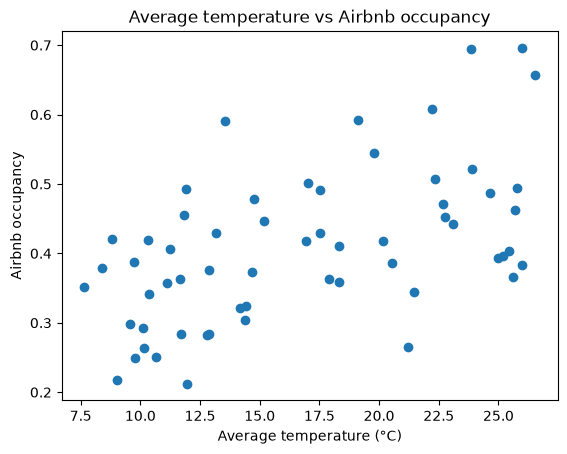

In [29]:
import matplotlib.pyplot as plt

plt.scatter(h3_final["avg_temperature"], h3_final["occupancy"])

plt.xlabel("Average temperature (°C)")
plt.ylabel("Airbnb occupancy")
plt.title("Average temperature vs Airbnb occupancy")

plt.show()

### Average Temperature vs Airbnb Occupancy
In this chart the we can see that higher average temperatures tend to be associated with higher Airbnb occupancy.

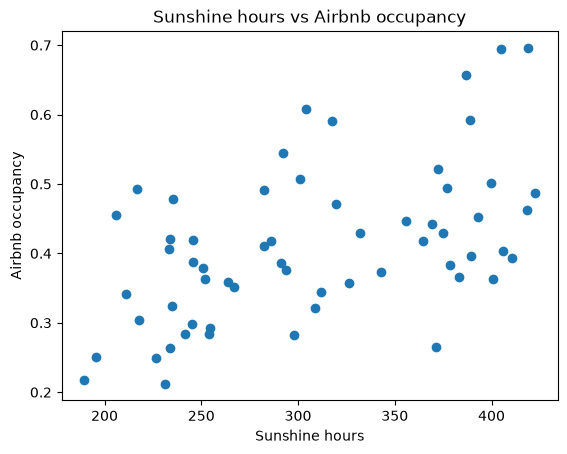

In [30]:
plt.scatter(h3_final["sunshine_hours"], h3_final["occupancy"])

plt.xlabel("Sunshine hours")
plt.ylabel("Airbnb occupancy")
plt.title("Sunshine hours vs Airbnb occupancy")

plt.show()

### H3 Conclusion

Weather showed the strongest relationship with Airbnb occupancy.

- Higher temperatures were associated with higher occupancy (r = 0.543).
- More sunshine was also associated with higher occupancy (r = 0.518).
- Precipitation had almost no relationship with occupancy (r = -0.108).
- Tourism activity had only weak relationships with occupancy (travellers: r = 0.047; nights: r = 0.178).

Overall, warmer and sunnier months tended to have higher Airbnb occupancy in our dataset. These results show relationships, not causation.